Reading logs from: /home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_17-35-00_to_2026-01-15_17-50-00/
Processing complete. Found 150 created blocks and 3000 import events.

Extracted Data Sample:
      Block    Node  ImportTime_ms
900   14361     leo          273.0
1350  14361  oliver          266.0
1650  14361  george          147.0
450   14361    dave          159.0
2700  14361     sam          184.0

Graph saved as 'import_times_graph.png'


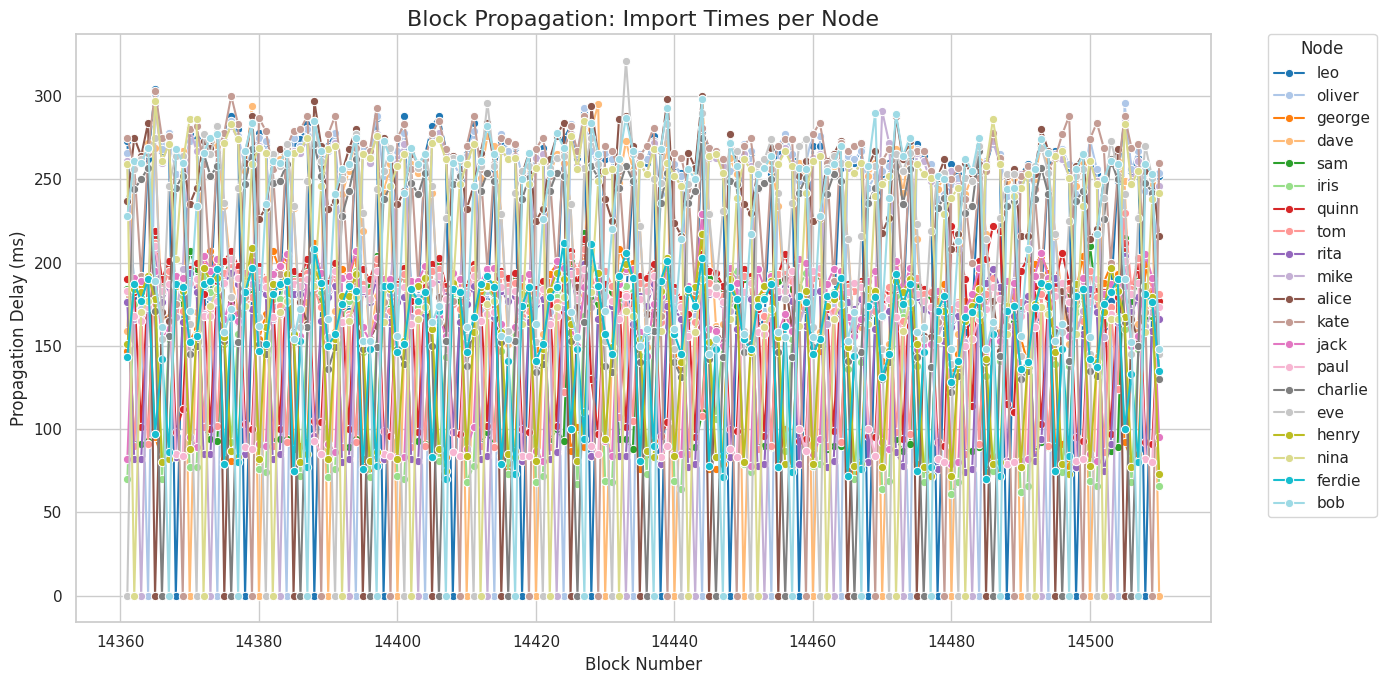

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# ---------------------------------------------------------
# STEP 1: CONFIGURATION
# ---------------------------------------------------------

# Path to the folder containing the 20 log files (alice.txt, bob.txt, etc.)
# Please verify this path matches your directory structure
log_dir = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_17-35-00_to_2026-01-15_17-50-00/'

# List of all node names to process
nodes = [
    "alice", "bob", "charlie", "dave", "eve", "kate", "leo", "mike", "nina", "oliver",
    "ferdie", "george", "henry", "iris", "jack", "paul", "quinn", "rita", "sam", "tom"
]

# ---------------------------------------------------------
# STEP 2: PARSE THE FILES
# ---------------------------------------------------------

block_creation_times = {} # Stores { block_num: creation_timestamp }
block_creators = {}       # Stores { block_num: creator_node_name }
import_events = []        # Stores raw import data

# Regex patterns
# Captures timestamps like: 2026-01-15 17:35:00.308
timestamp_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)")

# Captures block creation: "Prepared block for proposing at 14367"
created_pattern = re.compile(r"Prepared block for proposing at (\d+)")

# Captures block import: "Imported #14361"
imported_pattern = re.compile(r"Imported #(\d+)")

print(f"Reading logs from: {log_dir}")

for node in nodes:
    filepath = os.path.join(log_dir, f"{node}.txt")
    
    if not os.path.exists(filepath):
        # Skip if file doesn't exist to prevent crashing
        print(f"  - Warning: Log file not found for {node}")
        continue
        
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            
            # 1. Extract Timestamp from the start of the line
            ts_match = timestamp_pattern.search(line)
            if not ts_match: 
                continue
            
            try:
                # Parse timestamp (handles variable millisecond precision)
                ts_str = ts_match.group(1)
                # truncate to 6 digits for microseconds if necessary (python 3.11+ handles mixed, but safe check)
                if len(ts_str.split('.')[-1]) > 6:
                    ts_str = ts_str[:26] 
                current_time = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
            except ValueError:
                continue # Skip lines with unparseable timestamps

            # 2. Check if this node CREATED a block
            create_match = created_pattern.search(line)
            if create_match:
                block_num = int(create_match.group(1))
                # Store the creation time for this block
                block_creation_times[block_num] = current_time
                block_creators[block_num] = node
                continue

            # 3. Check if this node IMPORTED a block
            import_match = imported_pattern.search(line)
            if import_match:
                block_num = int(import_match.group(1))
                import_events.append({
                    'block': block_num,
                    'node': node,
                    'time': current_time
                })

print(f"Processing complete. Found {len(block_creation_times)} created blocks and {len(import_events)} import events.")

# ---------------------------------------------------------
# STEP 3: CALCULATE LATENCY (IMPORT TIME)
# ---------------------------------------------------------

data = []

for event in import_events:
    block_num = event['block']
    node_name = event['node']
    import_time = event['time']
    
    # We can only calculate delay if we know when the block was created
    if block_num in block_creation_times:
        creation_time = block_creation_times[block_num]
        creator = block_creators.get(block_num, "unknown")
        
        # If this node is the creator, propagation delay is 0
        if node_name == creator:
            delay_ms = 0.0
        else:
            # Calculate difference in milliseconds
            delta = import_time - creation_time
            delay_ms = delta.total_seconds() * 1000.0
        
        # Optional: Filter out negative values if clocks are slightly out of sync
        # delay_ms = max(0.0, delay_ms)
        
        data.append({
            "Block": block_num,
            "Node": node_name,
            "ImportTime_ms": delay_ms
        })

# ---------------------------------------------------------
# STEP 4: PLOT THE GRAPH
# ---------------------------------------------------------

if not data:
    print("No matching block data found! (Did the logs contain 'Prepared block' and 'Imported' lines for the same blocks?)")
else:
    df = pd.DataFrame(data)
    
    # Sort for cleaner plotting
    df = df.sort_values(by="Block")

    print("\nExtracted Data Sample:")
    print(df.head())

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # Create Line Plot
    sns.lineplot(
        data=df, 
        x="Block", 
        y="ImportTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab20", # High contrast palette for 20 nodes
        linewidth=1.5
    )

    plt.title("Block Propagation: Import Times per Node", fontsize=16)
    plt.xlabel("Block Number", fontsize=12)
    plt.ylabel("Propagation Delay (ms)", fontsize=12)
    
    # Adjust X-axis to integers only if range is small
    if df["Block"].nunique() < 20:
        plt.xticks(df["Block"].unique())

    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Node")

    plt.tight_layout()
    plt.savefig("import_times_graph.png", dpi=300)
    print("\nGraph saved as 'import_times_graph.png'")
    
    plt.show()

<Figure size 1000x400 with 0 Axes>

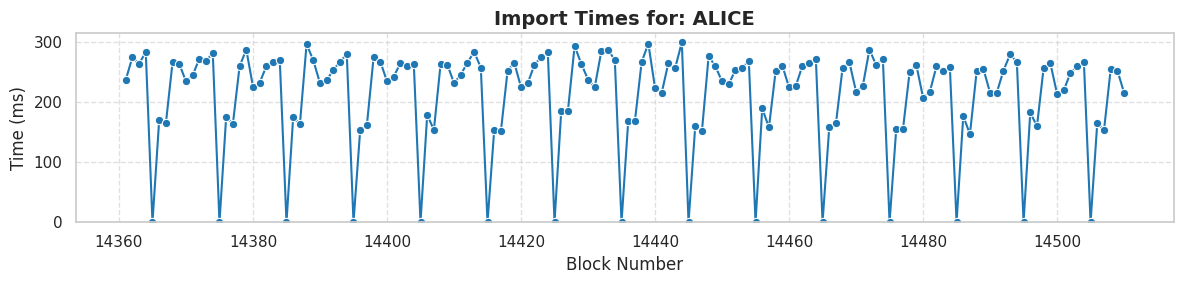

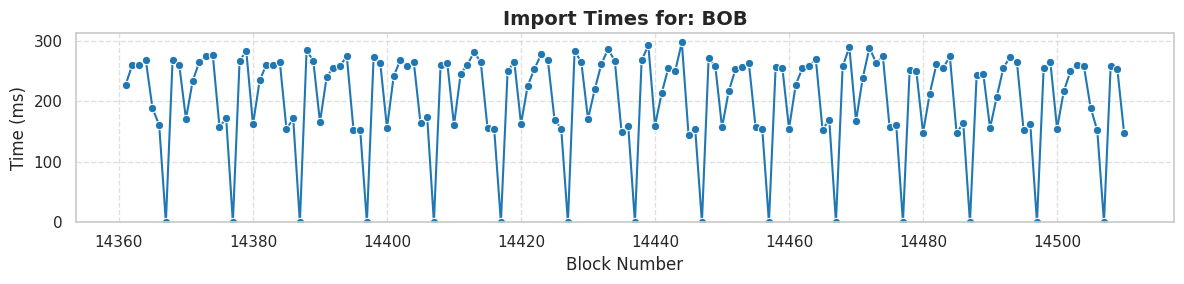

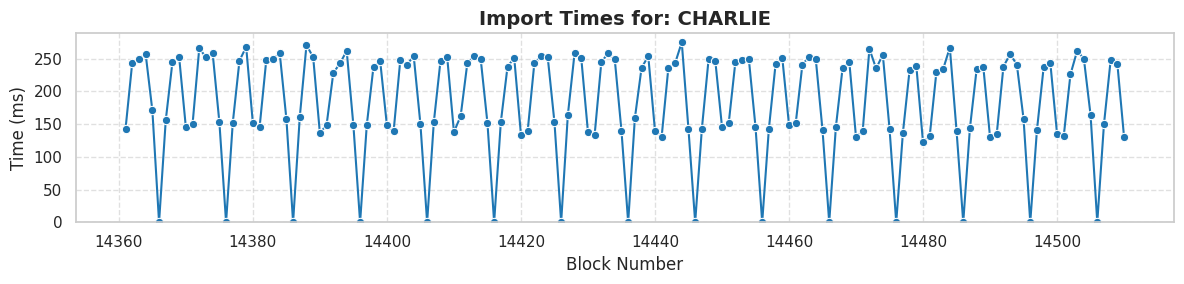

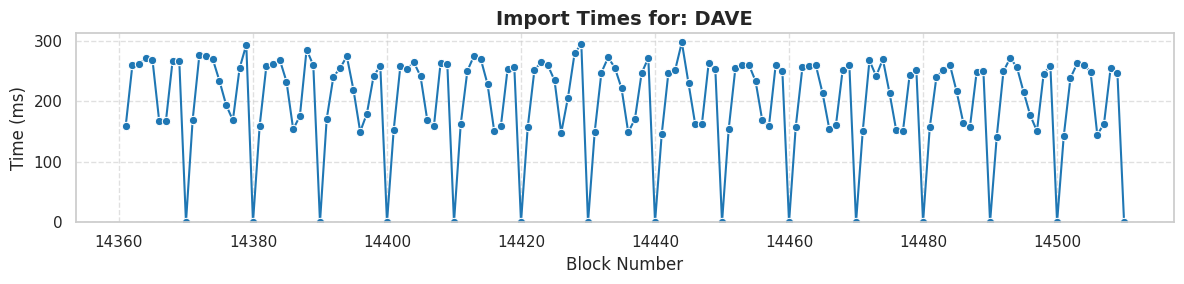

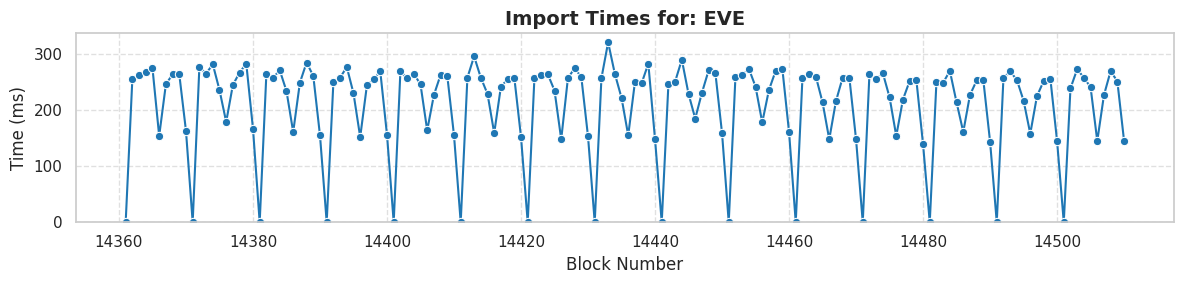

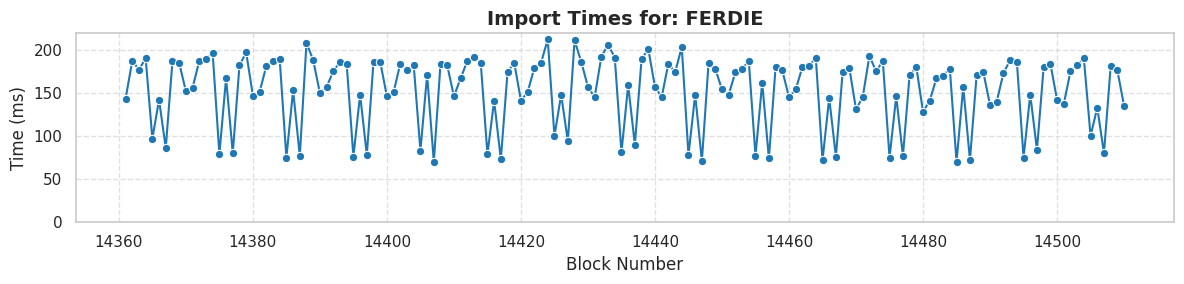

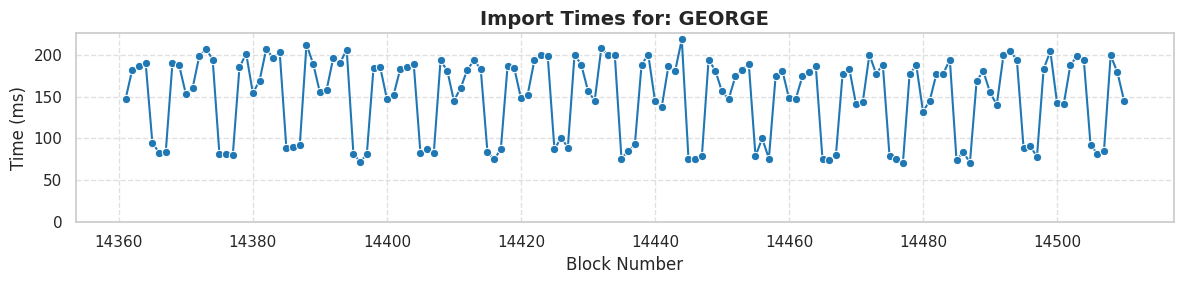

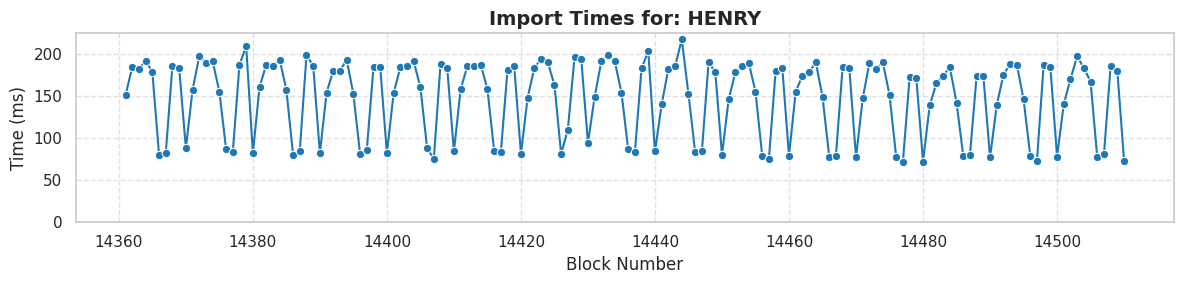

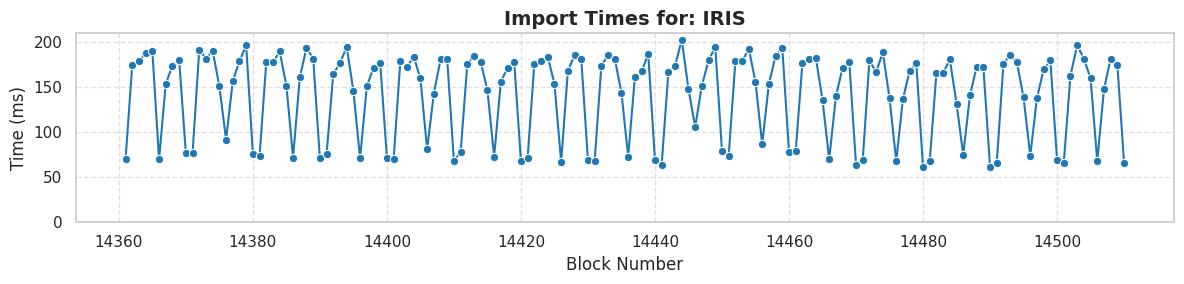

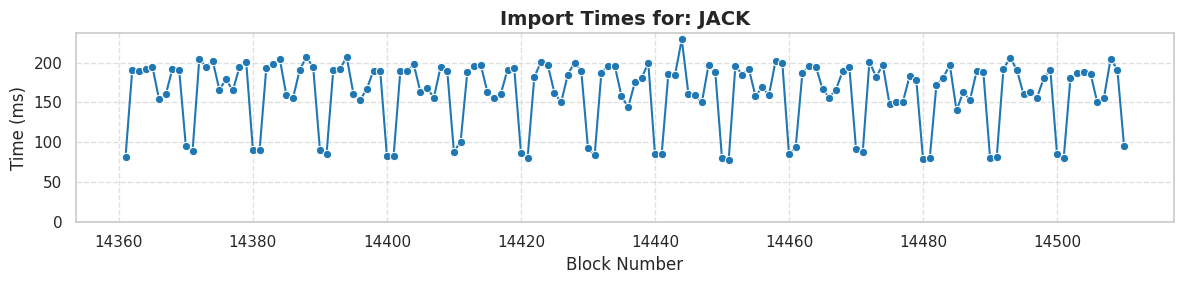

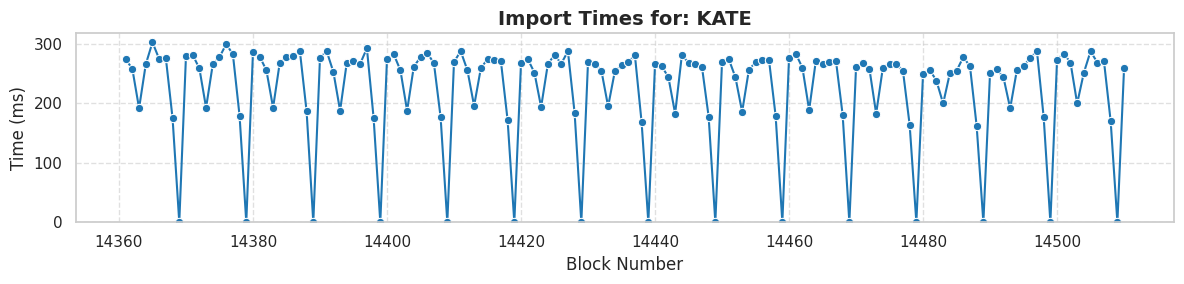

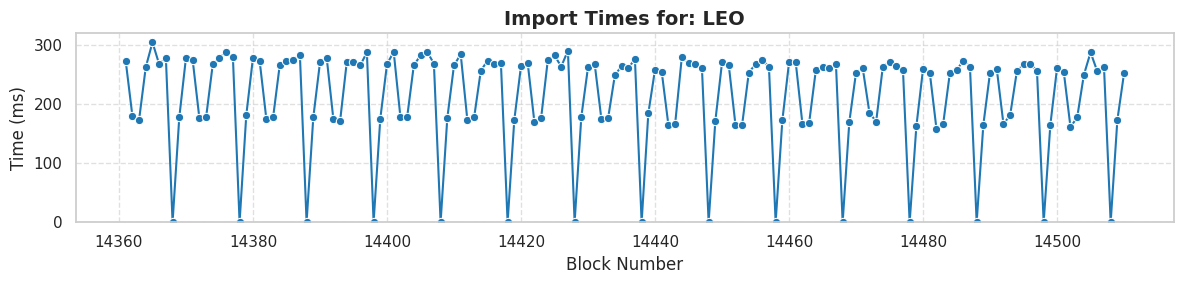

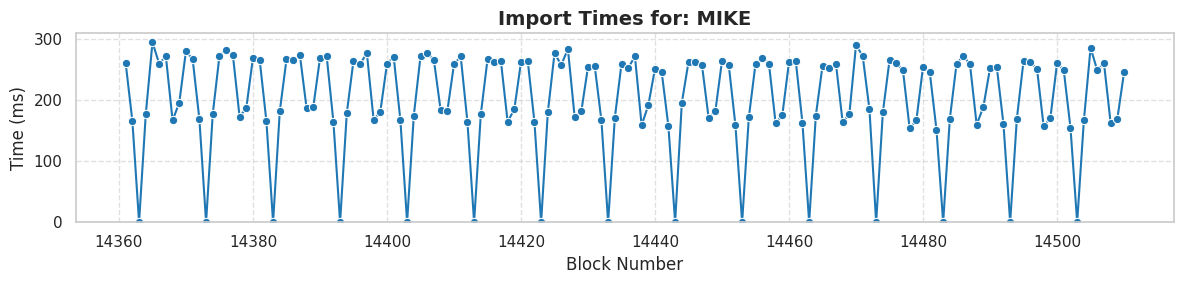

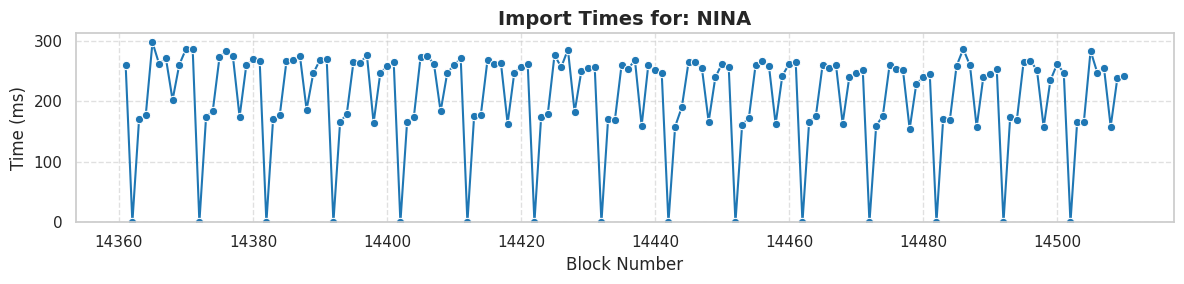

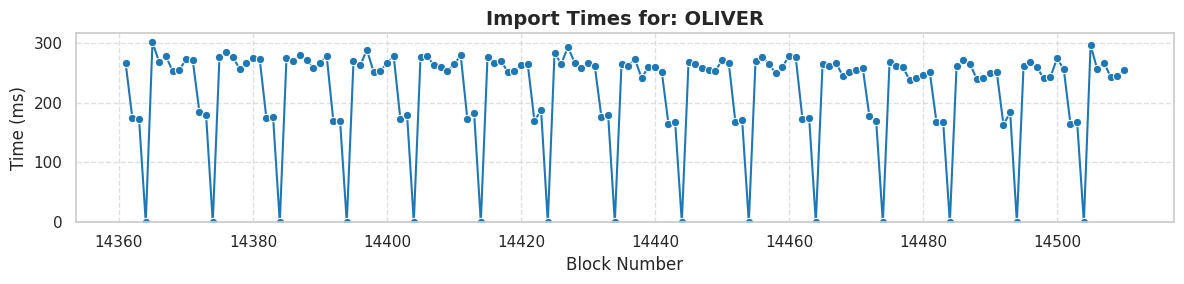

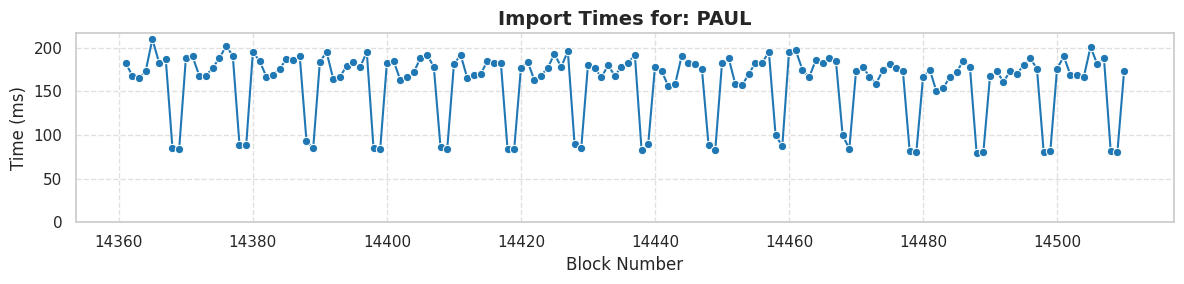

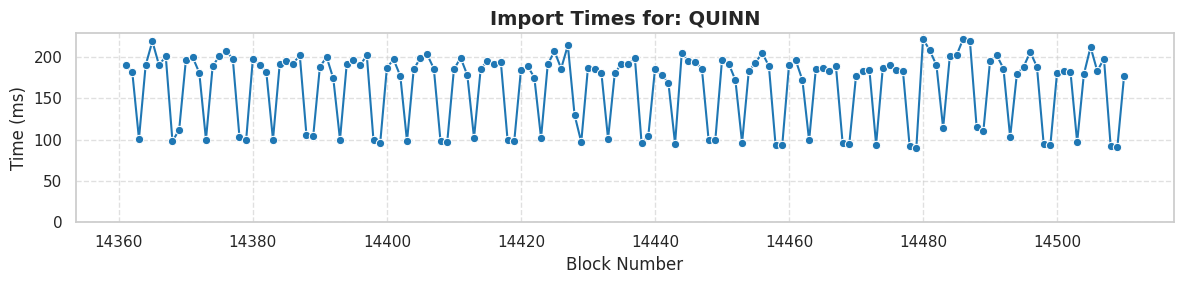

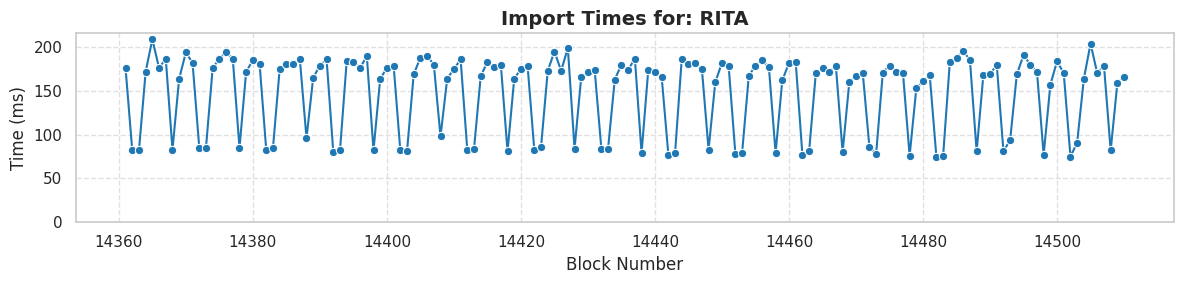

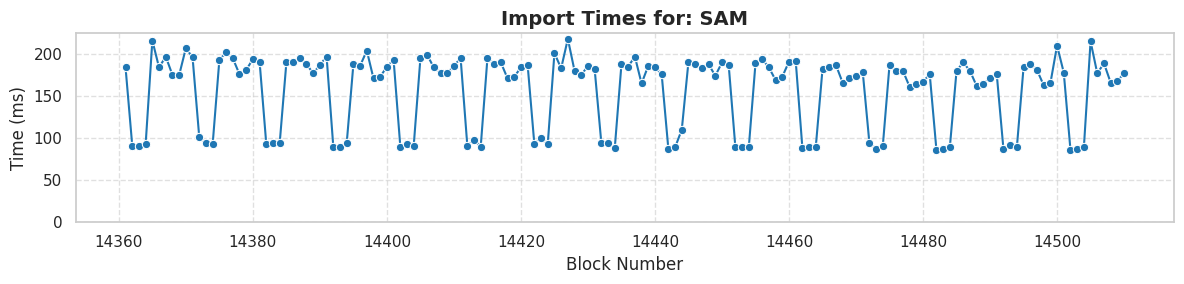

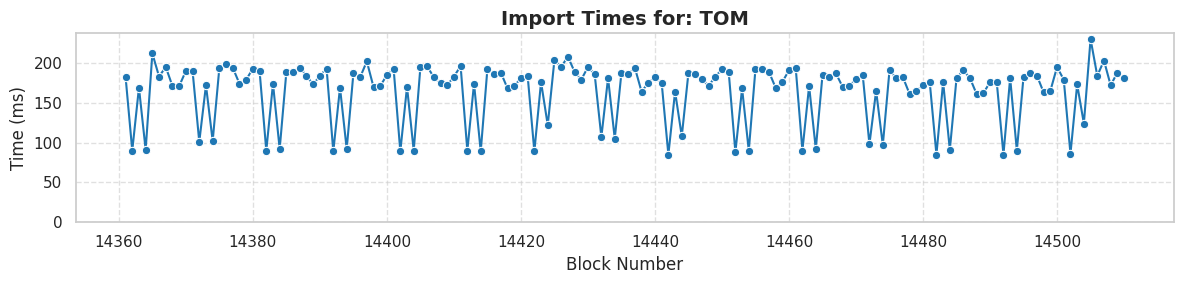

In [3]:
# Get a list of all unique nodes and sort them alphabetically
nodes = sorted(df['Node'].unique())

# Set the size for the individual graphs
plt.figure(figsize=(10, 4)) 

# Loop through each node and create a separate graph
for node in nodes:
    # 1. Filter the data for just this node
    node_data = df[df['Node'] == node]
    
    # 2. Create a new figure for this node
    plt.figure(figsize=(12, 3)) # Wide and short format
    
    # 3. Plot the line
    # We use a specific color (e.g., standard blue) or you can keep it colorful
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ImportTime_ms", 
        marker="o",
        color='tab:blue' 
    )
    
    # 4. formatting
    plt.title(f"Import Times for: {node.upper()}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # Optional: Force the Y-axis to start at 0 to see scale better
    plt.ylim(bottom=0)
    
    # Ensure X-axis shows every block integer (if list isn't too long)
    if len(df["Block"].unique()) < 50:
        plt.xticks(df["Block"].unique())
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # 5. Display the graph
    plt.show()